> Linear Recycle Cascade
> Using Decomposition and Propagation of Constraints

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from nested_sampler import NestedSampler
from helpers import Trellis, Corner, generate_sobol_points, train_surrogate, parity_plot
SHOW_PLOTS = False
%config InlineBackend.figure_formats = ["retina"] # high resolution in plots
# Figures are saved into a local clone of the GitHub repository of the thesis document:
from pathlib import Path
FIGURES_DIR = Path(r"C:\Users\kr326\Documents\MScThesis\figures")
from scipy.optimize import least_squares

In [117]:
R_GAS    = 8.314         # J/mol/K
E_1      = 48_000        # J/mol
E_2      = 55_000        # J/mol
C_A0     = 11.28         # mol/L
T_REF    = 328.15        # K; reference temperature
DCB_FRACTION_CAP, MCB_FLOOR, CONV_FLOOR = 0.05, 0.55, 0.70
T_LO, T_HI, TAU_LO, TAU_HI = 298.15, 353.15, 2, 30 # K, K, min, min
FEED = (C_A0, 0, 0)

def theta_nominal():
    """nominal arrhenius coefficients"""
    k1ref = 8.84e-3 * 60 * 0.5   # 1/min
    k2ref = k1ref / 8            # 1/min
    return k1ref * np.exp(E_1 / (R_GAS * T_REF)), k2ref * np.exp(E_2 / (R_GAS * T_REF))

th_1, th_2 = theta_nominal()

def cstr(c_in, temperature, tau):
    """simple steady state cstr implementation"""
    c_A_in, c_B_in, c_C_in = c_in
    k1 = th_1 * np.exp(-E_1 / (R_GAS * temperature))
    k2 = th_2 * np.exp(-E_2 / (R_GAS * temperature))
    c_A = c_A_in / (1.0 + k1 * tau)
    c_B = (c_B_in + k1 * tau * c_A) / (1.0 + k2 * tau)
    c_C = c_C_in + k2 * tau * c_B
    return c_A, c_B, c_C


> Simultaneous Sampling of the Flowsheet 

In [118]:
def linear_flowsheet(T_1, tau_1, T_2, tau_2):
    """entire flowsheet, for verification and simultaneous sampling"""
    c_A_R1, c_B_R1, c_C_R1 = cstr(FEED, T_1, tau_1)
    c_A_R2, c_B_R2, c_C_R2 = cstr((c_A_R1, c_B_R1, c_C_R1), T_2, tau_2)
    return dict(c_A_R1=c_A_R1, c_B_R1=c_B_R1, c_C_R1=c_C_R1, c_A_R2=c_A_R2, c_B_R2=c_B_R2, c_C_R2=c_C_R2)

def linear_constraints(x):
    T_1, tau_1, T_2, tau_2 = x
    res = linear_flowsheet(T_1, tau_1, T_2, tau_2)
    tot1 = res["c_A_R1"] + res["c_B_R1"] + res["c_C_R1"]
    tot2 = res["c_A_R2"] + res["c_B_R2"] + res["c_C_R2"]
    return [res["c_C_R1"] / tot1 - DCB_FRACTION_CAP,              # DCB fraction cap cstr-1
        MCB_FLOOR - res["c_B_R2"] / tot2,                         # MCB purity floor cstr-2
        CONV_FLOOR - (1 - res["c_A_R2"] / C_A0)]                  # conversion floor benzene cstr-2

simultaneous_results = NestedSampler(linear_constraints, [T_LO, TAU_LO, T_LO, TAU_LO], [T_HI, TAU_HI, T_HI, TAU_HI], num_live=2048).sample()


** INITIALIZING LIVE POINTS (2048)      0.01 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     7.2212e-01   143        0     3.0000e-01
     25     4.6540e-01   175      367     2.8947e-01
     50     3.4917e-01   204      679     2.8078e-01
     75     2.9248e-01   231      951     2.7342e-01
    100     2.4799e-01   257     1190     2.6711e-01
    125     2.1708e-01   285     1404     2.6159e-01
    150     1.8878e-01   316     1599     2.5665e-01
    175     1.6803e-01   340     1772     2.5235e-01
    200     1.5093e-01   367     1931     2.4847e-01
    225     1.3496e-01   394     2091     2.4461e-01
    250     1.2164e-01   418     2225     2.4143e-01
    275     1.1105e-01   446     2354     2.3841e-01
    300     1.0050e-01   478     2481     2.3547e-01
    325     9.3143e-02   508     2599     2.3277e-01
    350     8.5323e-02   540     2712     2.3022e-01
    375     7.9350e-02   564     2816     2.2789

In [119]:
def plot_simultaneous_results():
    live, dead, discard = simultaneous_results.live, simultaneous_results.dead, simultaneous_results.discarded
    T_1, tau_1, T_2, tau_2 = range(4)
    grid = Trellis(np.linspace(T_LO, T_HI, 4), np.linspace(TAU_LO, TAU_HI, 4),      # bin edges: T_1, tau_1
                xlabel="$T_2$ [K]", ylabel=r"$\tau_2$ [min]",
                col_label="$T_1$ [K]", row_label=r"$\tau_1$ [min]")
    grid.scatter(dead.x[:, T_2], dead.x[:, tau_2], dead.x[:, T_1], dead.x[:, tau_1], color="crimson", label="dead", s=6, alpha=0.5)
    pcs = grid.scatter(live.x[:, T_2], live.x[:, tau_2], live.x[:, T_1], live.x[:, tau_1], c=-live.value, s=8)
    grid.fig.colorbar(pcs[0], ax=grid.axes, label="margin (-max constraint)")
    grid.fig.legend(loc="outside upper right")

    grid = Corner(["$T_1$ [K]", r"$\tau_1$ [min]", "$T_2$ [K]", r"$\tau_2$ [min]"], [simultaneous_results.lb, simultaneous_results.ub])
    # grid.scatter(discard.x, s=2, color="red", label="discarded")
    grid.scatter(dead.x, s=2, color="0.75", label="dead")           # keywords as Axes.scatter
    grid.scatter(live.x, s=2, color="royalblue", label="live")
    grid.fig.legend(markerscale=4)
    plt.show()

if SHOW_PLOTS:
    plot_simultaneous_results()

> Decomposition using Surrogates

In [120]:
N_SAM_R1, N_SAM_R2    = 1024, 1024
BOUND_INFL  = 0.05

def inflate_bounds(Y, fraction, clip_low_end_at_zero:bool=False):
    """inflates bounds of Y in both directions by fraction of relative span on dimension"""
    bounds = np.array([Y.min(axis=0), Y.max(axis=0)])
    lo, hi = bounds[0], bounds[1]
    low_inf = np.maximum(lo - fraction * (hi - lo), 0) if clip_low_end_at_zero else lo - fraction * (hi - lo)
    inf_bounds = np.array([low_inf, hi + fraction * (hi - lo)])
    return inf_bounds


def generate_R1_training_data():
    # 1)  Sample R1 within [T, tau] bounds
    X_train = generate_sobol_points(N_SAM_R1, np.array([[T_LO, TAU_LO], [T_HI, TAU_HI]]))
    Y_train = np.empty(shape=(X_train.shape[0], 3)) # 3 concentrations
    G1_train = np.empty(shape=(X_train.shape[0], 1)) # g1 constraint violation
    for i, (T_1, tau_1) in enumerate(X_train):
        Y_train[i] = cstr(FEED, T_1, tau_1)
        c_A_R1, c_B_R1, c_C_R1 = Y_train[i]
        G1_train[i] = c_C_R1 / (c_A_R1 + c_B_R1 + c_C_R1) - DCB_FRACTION_CAP
    bounds = inflate_bounds(Y_train, BOUND_INFL, True)

    return X_train, Y_train, G1_train, bounds

R1_X_train, R1_Y_train, R1_G1_train, R1_U_inf_bounds = generate_R1_training_data()

width 64 (49 s)   CV rmse/std per width: 4: 0.0127, 8: 0.0052, 16: 0.0024, 32: 0.0022, 64: 0.0020, 128: 0.0026
  y0                         0.004    0.04 % of range
  y1                         0.003    0.06 % of range
  y2                         0.004    0.05 % of range
width 32 (36 s)   CV rmse/std per width: 4: 0.0031, 8: 0.0018, 16: 0.0012, 32: 0.0011, 64: 0.0012
  y0                         0.000    0.03 % of range


(<Figure size 320x320 with 1 Axes>,
 array([[<Axes: title={'center': 'y0'}>]], dtype=object))

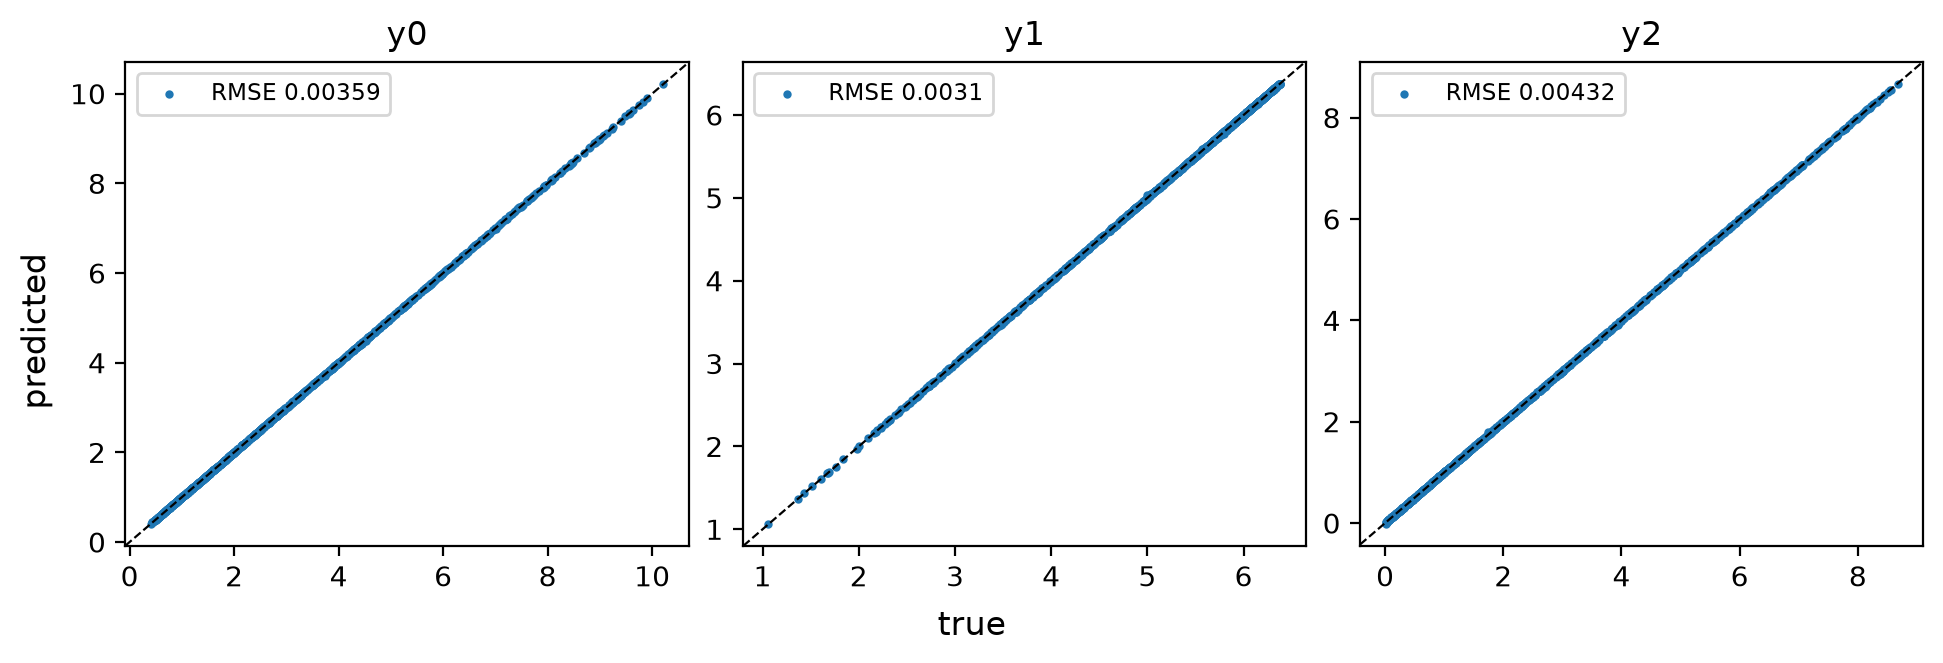

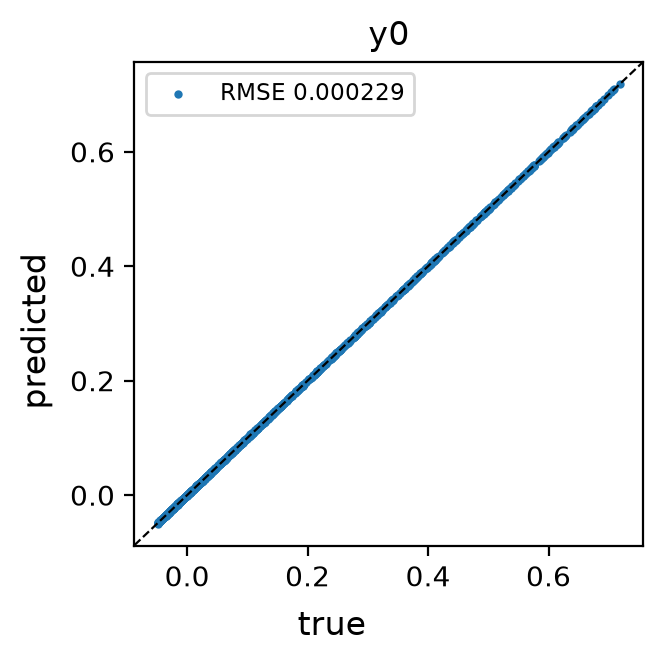

In [121]:
F_R1_surr, _, Y_oof_R1 = train_surrogate(R1_X_train, R1_Y_train, path="F_R1_surr")
# generate a parity plot for validation
parity_plot(R1_Y_train, Y_oof_R1)
# Fit a G_R1 surrogate to the data
G1_R1_surr, _, G1_oof_R1 = train_surrogate(R1_X_train, R1_G1_train, path="G1_R1_surr")
parity_plot(R1_G1_train, G1_oof_R1)

In [123]:
def residual(z, c):
    """compute the residual of surrogate F1 prediction on z to the expected output c"""
    return F_R1_surr(scale_T1_tau1(z)) - c

# # Test
# def test():
#     lo = np.array([T_LO, TAU_LO])
#     hi = np.array([T_HI, TAU_HI])
#     z_k = (R1_X_train[3] - lo) / (hi - lo)
#     print(residual(z_k, R1_Y_train[3]))

# test()
def scale_T1_tau1(x):
    lo = np.array([T_LO, TAU_LO])
    hi = np.array([T_HI, TAU_HI])
    return lo + x * (hi - lo)

def solve(c):
    """Solve NLP given a target inlet of R2, find T1, tau1 producing them with F_R1(T1, tau1)"""
    result = least_squares(lambda z: residual(z, c), x0=[0.5, 0.5], bounds=(0, 1))
    return scale_T1_tau1(result.x), np.max(np.abs(result.fun))

# Test
# print(solve(R1_Y_train[30]))
# print(R1_X_train[30])

TOL = np.max(np.abs(R1_Y_train - Y_oof_R1))
def coupling(c):
    """Couple both conditions:
    -reachable: r - tol <= 0
    -feasible:  G1(v*)  <= 0
    A (return value <= 0) indicates that R1 *can produce* c *feasibly*.
    """
    v_star, r = solve(c)
    g1 = G1_R1_surr(v_star)[0]
    return max(r - TOL, g1)

true_R2_evals = 0
def r2_constraints(x):
    c_A_R1, c_B_R1, T_2, tau_2 = x
    c_C_R1 = C_A0 - c_A_R1 - c_B_R1
    m = coupling((c_A_R1, c_B_R1, c_C_R1))
    if m > 0:
        return [m, m, m]

    # CSTR-1 is likely feasible, hence evaluate CSTR-2
    global true_R2_evals
    true_R2_evals += 1

    c_A_R2, c_B_R2, c_C_R2 = cstr((c_A_R1, c_B_R1, c_C_R1), T_2, tau_2)
    g2 = MCB_FLOOR - c_B_R2 / (c_A_R2 + c_B_R2 + c_C_R2)
    g3 = CONV_FLOOR - (1 - c_A_R2 / C_A0)
    return m, g2, g3

# NOTE: [:2] slices for the first two concentrations, due to mass conservation we need to enforce mass balance and hence don't suggest c_C_R1
r2_results = NestedSampler(r2_constraints, lb=[*R1_U_inf_bounds[0][:2], T_LO, TAU_LO], ub=[*R1_U_inf_bounds[1][:2], T_HI, TAU_HI]).sample()


** INITIALIZING LIVE POINTS (256)      0.67 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     6.0098e+00     1        0     3.0000e-01
     25     8.5723e-01     2      240     2.4890e-01
     50     5.4543e-01     3      359     2.2681e-01
     75     3.9188e-01     4      457     2.1009e-01
    100     2.7200e-01     5      558     1.9415e-01
    125     1.7760e-01    12      673     1.7747e-01
    150     1.3120e-01    19      766     1.6503e-01
    175     8.1177e-02    30      869     1.5227e-01
    200     5.3799e-02    45      962     1.4160e-01
    225     3.4865e-02    61     1045     1.3271e-01
    250     2.3718e-02    86     1116     1.2555e-01
    275     1.3797e-02   117     1193     1.1822e-01
    300     8.8807e-03   139     1250     1.1307e-01
    325     5.8983e-03   164     1293     1.0933e-01
    350     4.4930e-03   180     1321     1.0697e-01
    375     2.8314e-03   201     1350     1.0457e

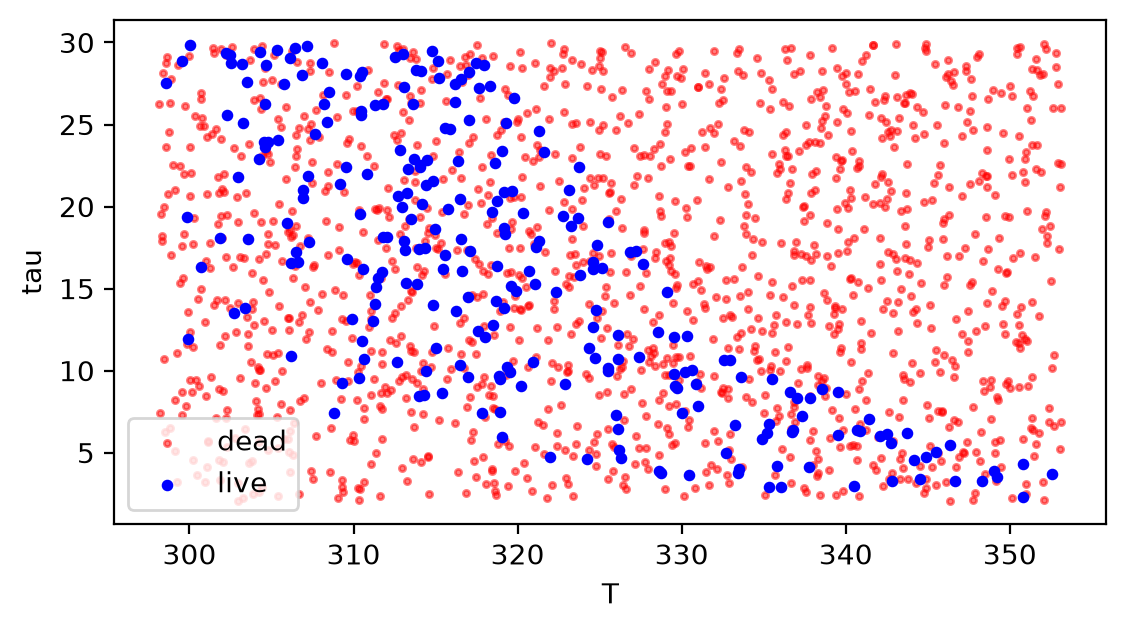

In [134]:
def scatter_results(results, ax):
    ax.scatter(results.dead.x[:, 2], results.dead.x[:, 3], s=5, color='r', label='dead', alpha=0.5)
    ax.scatter(results.live.x[:, 2], results.live.x[:, 3], s=10, color='blue', label='live')
    # ax.scatter(results.discarded.x[:, 2], results.discarded.x[:, 3], s=10, color='gray', alpha=0.5, label='discarded')
    ax.set_xlabel("T")
    ax.set_ylabel("tau")
    ax.set_aspect(1)
    ax.legend()

fig, ax = plt.subplots(1, 1)
scatter_results(r2_results, ax)
